## Run the cell to run the agent - final line is calling the train function - adjust hyperparameters as need be

In [1]:
import torch
from torch import nn
import torch.nn.functional as F
import numpy as np
import gymnasium as gym
import ale_py
import numpy as np
import cv2
import matplotlib.pyplot as plt
import tqdm
from tqdm import tqdm
import os
import random
base_dir = os.getcwd()
path = os.path.join(base_dir, 'outputs')
os.makedirs(path, exist_ok=True)
import pickle

env = gym.make("LunarLander-v3")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

class ActNet(nn.Module):
    def __init__(self):
        
        super(ActNet, self).__init__()
        self.lin1 = nn.Linear(8, 4)
       



    def forward(self, x):

        x = self.lin1(x)
        a = F.softmax(input=x, dim=-1)
        return a

class ValNet(nn.Module):
    def __init__(self):
        
        super(ValNet, self).__init__()
        self.lin1 = nn.Linear(8, 1)
    


    def forward(self, x):

        x = self.lin1(x)
    
        return x
    

def clipped(obj, eps):
    if obj<-eps:
        return -eps
    if obj>eps:
        return eps
    else:
        return obj

def observation_converter(state, d):
    if isinstance(state, torch.Tensor):
        state = state
    else:
        state = torch.from_numpy(state).to(d)
    return state

def actions_or_val_from_mod(state, model):
    return model(state)

def tensor_categorical(dist):
    return torch.distributions.Categorical(dist)

def choose_from_categorical(categor_dist):
    return categor_dist.sample()

def logged_prob(categorical_dist, action):
    return categorical_dist.log_prob(action)

def item_action(action):
    return action.item()

def trajectory_timestep(state, action, reward, log_p, terminated, val, target_append):
        return target_append.append([state, action, reward, log_p.item(), terminated, val.detach()])

def step(action):
        if isinstance(action, torch.Tensor):
            action = action.item()
        new_state, reward, terminated, truncated, info = env.step(action)
        return new_state, reward, terminated, truncated, info

def sample_trajectory(trajectory, batch_size):
    return random.sample(trajectory, batch_size)

def rewards_to_go(trajectory, gam):
        discounted_return = []
        r_t_d = 0
        for t_i in reversed(trajectory):
            if t_i[4]:
                r_t_d = 0
            r_t_d = t_i[2] + r_t_d * gam 
            discounted_return.insert(0, r_t_d)
        return discounted_return

def get_all_val(trajectory):
    return [v[-1] for v in trajectory]

def advantage(rew_to_go, val, trajectory):
    final_adv = []
    for i in range(len(rew_to_go)):
        adv = rew_to_go[i] - val[i]
        final_adv.append(adv)
    return final_adv
    

def standardised_advantage(adv):
        adv = torch.tensor(adv, dtype=torch.float32)
        mean_adv = adv.mean()
        std_adv = adv.std()
        stand_adv = adv - mean_adv / (std_adv + 1e-10)
        return stand_adv

def loss(traj, model, batch_size, norm_adv, rew_to_go, eps):
    loss=0
    for t_i in range(batch_size):
        if model == actor:
            new_act = model(traj[t_i][0])
            old_act = traj[t_i][1]
            new_dist = tensor_categorical(new_act)
            logged = logged_prob(new_dist, old_act)
            ratio = torch.exp(logged - traj[t_i][3])
            obj = ratio * norm_adv[t_i]
            loss += torch.max(-obj, -clipped(obj, torch.tensor(eps, dtype=float)))
        else:
            val = model(traj[t_i][0])
            loss += ((val - rew_to_go[t_i])**2)    
    final_loss = loss / batch_size
    return final_loss
        


def train( model_act, model_val, env, timesteps, batch_size, val_opt, act_opt, timesteps_target, device, gamma, eps):
    trajectory = []
    all_trajectory = []
    done = False
    timesteps_trained = 0
    progress = tqdm(total=timesteps_target)
    while not done:
        state, info = env.reset()
        for k in range(timesteps):
            state = observation_converter(state, device)
            action_probs = actions_or_val_from_mod(state, model_act)
            torched_probs = tensor_categorical(action_probs)
            action = choose_from_categorical(torched_probs)
            logged_p = logged_prob(torched_probs, action)
            new_state, reward, terminated, truncated, info = step(action)
            val = actions_or_val_from_mod(state, model_val)
            trajectory.append([state, action, reward, logged_p.item(), terminated, val.detach() ])
            #all_trajectory.append([state, action, reward, logged_p.item(), terminated, val.detach() ])
            
            if not terminated or not truncated:
                state = new_state
            else:
                state, info = env.reset()

        samples = sample_trajectory(trajectory, batch_size)
        rewards_to_go_ALL = rewards_to_go(samples, gamma)
        val_net_vals = get_all_val(samples)
        all_advantage = advantage(rewards_to_go_ALL, val_net_vals, samples)
        normed_advantage = standardised_advantage(all_advantage)
        
        policy_loss = loss(samples, model_act, batch_size, normed_advantage,rewards_to_go_ALL, eps)
        val_loss = loss(samples, model_val, batch_size, normed_advantage, rewards_to_go_ALL, eps)
        
        val_opt.zero_grad()
        val_loss.backward()
        val_opt.step()

        act_opt.zero_grad()
        policy_loss.backward()
        act_opt.step()
        
        if timesteps_trained == timesteps_target:
            done = True
        else:
            timesteps_trained += 1
            progress.update(1)
            
        
        all_trajectory.append(trajectory)
        trajectory = []

        if timesteps_trained == 100:
            torch.save(actor.state_dict(), path + f'Weights for actor {timesteps_trained}')
            torch.save(critic.state_dict(), path + f'Weights for critic {timesteps_trained}')
            fin_traj = []
            for traj in tqdm(all_trajectory):
                t_traj = []
                for t in traj:
                    t_traj.append((t[2], t[4]))
                fin_traj.append(t_traj)
            with open('trajecory_stream_test.pkl', 'wb') as f:
                pickle.dump(fin_traj, f)
            #torch.save(torch.tensor(all_trajectory), path+f'Trajectory {timesteps}')
            
            
        if timesteps_trained == 1000:
            torch.save(actor.state_dict(), path + f'Weights for actor {timesteps_trained}')
            torch.save(critic.state_dict(), path + f'Weights for critic {timesteps_trained}')
            #torch.save(torch.tensor(all_trajectory), path+f'Trajectory {timesteps}')

        
        if timesteps_trained == 10000:
            torch.save(actor.state_dict(), path + f'Weights for actor {timesteps_trained}')
            torch.save(critic.state_dict(), path + f'Weights for critic {timesteps_trained}')
            #torch.save(torch.tensor(all_trajectory), path+f'Trajectory {timesteps}')


        if timesteps_trained == 5000:
            torch.save(actor.state_dict(), path + f'Weights for actor {timesteps_trained}')
            torch.save(critic.state_dict(), path + f'Weights for critic {timesteps_trained}')
            #torch.save(torch.tensor(all_trajectory), path+f'Trajectory {timesteps}')
        
        if timesteps_trained == 10000:
            torch.save(actor.state_dict(), path + f'Weights for actor {timesteps_trained}')
            torch.save(critic.state_dict(), path + f'Weights for critic {timesteps_trained}')
            #torch.save(torch.tensor(all_trajectory), path+f'Trajectory {timesteps}')

        if timesteps_trained == 15000:
            torch.save(actor.state_dict(), path + f'Weights for actor {timesteps_trained}')
            torch.save(critic.state_dict(), path + f'Weights for critic {timesteps_trained}')
            #torch.save(torch.tensor(all_trajectory), path+f'Trajectory {timesteps}')

        if timesteps_trained == 1000000:
            torch.save(actor.state_dict(), path + f'Weights for actor {timesteps_trained}')
            torch.save(critic.state_dict(), path + f'Weights for critic {timesteps_trained}')
            #torch.save(torch.tensor(all_trajectory), path+f'Trajectory {timesteps}')

        if timesteps_trained == 1500000:
            torch.save(actor.state_dict(), path + f'Weights for actor {timesteps_trained}')
            torch.save(critic.state_dict(), path + f'Weights for critic {timesteps_trained}')
            #torch.save(torch.tensor(all_trajectory), path+f'Trajectory {timesteps}')

        if timesteps_trained == 20000:
            torch.save(actor.state_dict(), path + f'Weights for actor {timesteps_trained}')
            torch.save(critic.state_dict(), path + f'Weights for critic {timesteps_trained}')
            fin_fin_traj = []
            for traj in tqdm(all_trajectory):
                t_traj_fin = []
                for t in traj:
                    
                    a = t[1].detach().cpu().numpy() if isinstance(t[1], torch.Tensor) else t[1]
                    v = t[5].detach().cpu().numpy() if isinstance(t[5], torch.Tensor) else t[5]
    
                    t_traj_fin.append((t[2],t[4]))
                fin_fin_traj.append(t_traj_fin)
            
            
            with open('trajecory_stream.pkl', 'wb') as f:
                pickle.dump(fin_fin_traj, f)
            #torch.save(torch.tensor(all_trajectory), path+f'Trajectory {timesteps}')

        
        
        #trajectory.pop(0)
        #print(torch.stack(rewards_to_go_ALL).detach().numpy().mean())
    return model_act.state_dict(), model_val.state_dict(), all_trajectory

        


        
        

actor = ActNet().to(device)
opt = torch.optim.Adam(actor.parameters(), lr=0.0003)

critic = ValNet().to(device)
opt_critic = torch.optim.Adam(critic.parameters(), lr=0.0003)
batch_size = 64

weights_act, weights_val, all_traj = train(actor, critic, env, 1000, 1000, opt_critic, opt, 20000, device, 0.99, 0.2)

cpu


100%|██████████| 20000/20000 [2:55:15<00:00,  1.90it/s]


In [ ]:
print(len(all_traj))
print(len(all_traj[0]))
print(len(all_traj[0][0]))
print(len(all_traj[0][0][0]))
print((all_traj[0][0]))


ep_rewards = []
ep_r = 0
eps = 0
for t in tqdm(all_traj):
    for i in t:
        if i[4]:
            ep_r += i[2]
            ep_rewards.append(ep_r)
            ep_r = 0
            eps += 1
        else:
            ep_r += i[2]




1001
1000
6
8
[tensor([-0.0071,  1.3998, -0.7150, -0.4928,  0.0082,  0.1620,  0.0000,  0.0000]), tensor(2), 2.0149650576121987, -1.9737026691436768, False, tensor([0.4403])]


100%|██████████| 1001/1001 [00:00<00:00, 4649.39it/s]


922863


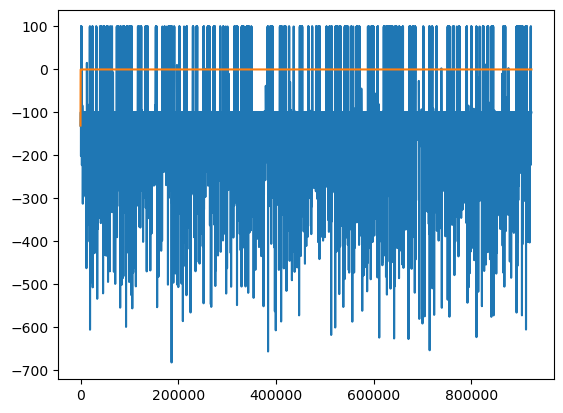

In [ ]:
print(eps)
moving_average = []
counter = 1
for e in ep_rewards:
    moving_average.append(e/counter)
    counter += 1
plt.plot(ep_rewards)
plt.plot(moving_average)
plt.show()


In [ ]:
print()

In [ ]:

fin_traj = []
for traj in tqdm(all_traj):
    t_traj = []
    for t in traj:
        s = t[0].detach().cpu().numpy() if isinstance(t[0], torch.Tensor) else t[0]
        a = t[1].detach().cpu().numpy() if isinstance(t[1], torch.Tensor) else t[1]
        v = t[5].detach().cpu().numpy() if isinstance(t[5], torch.Tensor) else t[5]
    
        t_traj.append((s, a, t[2], t[3], t[4], t[5], v))
    fin_traj.append(t_traj)

NameError: name 'all_traj' is not defined

In [ ]:
import sys
test = fin_traj[0][0][0]

print(sys.getsizeof(test))
print(test)
print(32*500000*480)

88
tensor(1)
7680000000


In [ ]:
episode_rewards = []
ep_counter = 0
ep_rew = 0
all_rew = 0
print(all_traj)
for t in all_traj:
    for i in t:
        if i[4]:
            ep_rew += i[2]
            episode_rewards.append(ep_rew)
            ep_rew = 0
            ep_counter += 1
        else:
            ep_rew += i[2]
plt.scatter([i for i in range(len(episode_rewards))],episode_rewards)
print(ep_counter)


In [ ]:
print(ep_counter)

92408
